# CODEx Single‑Sample Analysis Demo
This notebook demonstrates how to:
1. **Load** spatial CODEx datasets (UPMC, Charville, DFCI)
2. **Inspect** available cell‑type annotations
3. **Define** tumor centre mappings for feature extraction
4. **Run** the TIC single‑sample analysis pipeline
5. **Visualise** cross‑region causal effects with automatic pseudo‑time direction correction

> *Update the `EXP_ROOT` path to your own workspace before executing.*

In [3]:
import warnings, os, pickle
warnings.filterwarnings('ignore')

from tic.data import list_codex_datasets
from tic.data.loader import load_codex_dataset

from pathlib import Path
from typing import List
from tqdm import tqdm
from tic.plotting.pseudotime import plot_biomarker_trends
from tic.wrappers.feature import FeatureWrapper
from tic.wrappers.pseudotime import PseudotimeWrapper
from tic.wrappers.causal import CausalWrapper
from utils.dataset.codex_upmc import UPMC_EMT_GENES



In [4]:
# root directory to save experiment outputs
EXP_ROOT = "../tutorial/example_out/multi_regions"  # <-- EDIT ME

# enumerate available regions
upmc_regions      = list_codex_datasets(dataset='upmc')
charville_regions = list_codex_datasets(dataset='charville')
dfci_regions      = list_codex_datasets(dataset='dfci')

print(f"UPMC      regions: {len(upmc_regions)}")
print(f"Charville regions: {len(charville_regions)}")
print(f"DFCI      regions: {len(dfci_regions)}")


UPMC      regions: 308
Charville regions: 292
DFCI      regions: 58


In [ ]:
# Load one example region per dataset to inspect cell types
upmc_example      = load_codex_dataset('upmc', region_id=upmc_regions[0])
charville_example = load_codex_dataset('charville', region_id=charville_regions[0])
dfci_example      = load_codex_dataset('dfci', region_id=dfci_regions[0])

def tumor_types(adata):
    cts = adata.obs['cell_type'].unique()
    return [ct for ct in cts if 'tumor' in ct.lower()]

print("Tumor cell types:")
print("  UPMC      :", tumor_types(upmc_example))
print("  Charville :", tumor_types(charville_example))
print("  DFCI      :", tumor_types(dfci_example))

# mapping used by FeatureWrapper
Tumor_Cell_Mapping = {
    "upmc": tumor_types(upmc_example),
    "charville": tumor_types(charville_example),
    "dfci": tumor_types(dfci_example),
}


In [ ]:
print('gene names per dataset:')
print('UPMC     :', upmc_example.var_names.tolist())
print('Charville:', charville_example.var_names.tolist())
print('DFCI     :', dfci_example.var_names.tolist())


## Single‑Sample Analysis Pipeline
We will compute:
1. **Cell‑type composition features** (`recipe='tme_default'`).
2. **Pseudotime** (`TIC.PseudotimeWrapper`).
3. **Biomarker trends** over pseudotime for EMT markers.
4. **Granger causality** of cell‑type predictors to target biomarkers.

Outputs are saved under `EXP_ROOT/<dataset>/<region_id>/`.

In [3]:
def single_sample_analysis(dataset: str, region_ids: List[str], out_dir: str, method: str = 'composition') -> None:
    """
    Run TIC single-sample workflow for multiple regions.
    For each region, extract features and perform single-sample analysis:
        1. Feature extraction
        2. Pseudotime inference
        3. Biomarker trend plotting
        4. Causal inference analysis
        5. Result saving

    Output structure:
    out_dir/
        region_id/
            biomarker_trends.png
            metrics.csv
            causal/
                biomarker/
                    bar.png
                    volcano.png
                    heatmap.png
                    results.pkl
    """
    os.makedirs(out_dir, exist_ok=True)

    for rid in tqdm(region_ids, desc=f'[{dataset}]'):
        adata  = load_codex_dataset(dataset=dataset, region_id=rid)
        genes  = set(adata.var_names)
        rdir   = os.path.join(out_dir, rid)
        os.makedirs(rdir, exist_ok=True)

        # Feature extraction
        fw = FeatureWrapper(
            recipe='tme_default',
            centre_types=Tumor_Cell_Mapping[dataset],
            graph_params={'method': 'voronoi'},
            subgraph_params={'strategy': 'radius', 'radius': 75},
        )
        fea_adata = fw.fit(adata)

        # Pseudotime inference
        ptw      = PseudotimeWrapper(rep_key=method, output_dir=rdir)
        pt_adata = ptw.fit(fea_adata)
        ptw.metrics.to_csv(os.path.join(rdir, 'metrics.csv'), index=False)

        # Biomarker trends
        plot_biomarker_trends(
            adata=pt_adata,
            selected_biomarkers=UPMC_EMT_GENES,
            x_transform='bin+normalize',
            y_transform='normalize',
            bins=100,
            save_path=os.path.join(rdir, 'biomarker_trends.png'),
        )

        # Causal inference
        causal_root = Path(rdir) / "causal"
        causal_root.mkdir(exist_ok=True)
        for biomarker in set(UPMC_EMT_GENES) & set(genes):
            dest = causal_root / biomarker
            dest.mkdir(exist_ok=True)

            cw = CausalWrapper(
                outcome=biomarker,
                include_extractors=('celltype_gene_count',),
                method='granger_causality',
                bins=100,
                method_kwargs={'maxlag': 3},
            )
            c_adata = cw.fit(pt_adata)
            cw.plot(c_adata, kind='bar',      save_path=dest/'bar.png')
            cw.plot(c_adata, kind='volcano',  save_path=dest/'volcano.png')
            cw.plot(c_adata, kind='heatmap',  save_path=dest/'heatmap.png')

            with open(dest/'results.pkl', 'wb') as fh:
                pickle.dump(cw.results, fh)


In [ ]:
# >>> Uncomment to run a quick test on the first 2 UPMC regions
TEST_DIR = Path(EXP_ROOT) / 'EXP_UPMC_DEMO'
single_sample_analysis('upmc', upmc_regions[:2], str(TEST_DIR))


## Cross‑Region Causal Heatmap
To compare causal effects across regions while accounting for pseudo‑time direction (EMT vs MET), we use `plot_cross_region_causal_heatmap`. Specify `expected_sign` for the target biomarker:

* **E‑markers** → expected positive correlation
* **M‑markers** → expected negative correlation

In [1]:
from tic.plotting import plot_cross_region_causal_heatmap

/opt/anaconda3/envs/test_tic_env_0511/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: title={'center': "Causal effect on 'PanCK' (metric: rms, p ≤ 0.05) Data from Charville"}, ylabel='Regions (n=292)'>

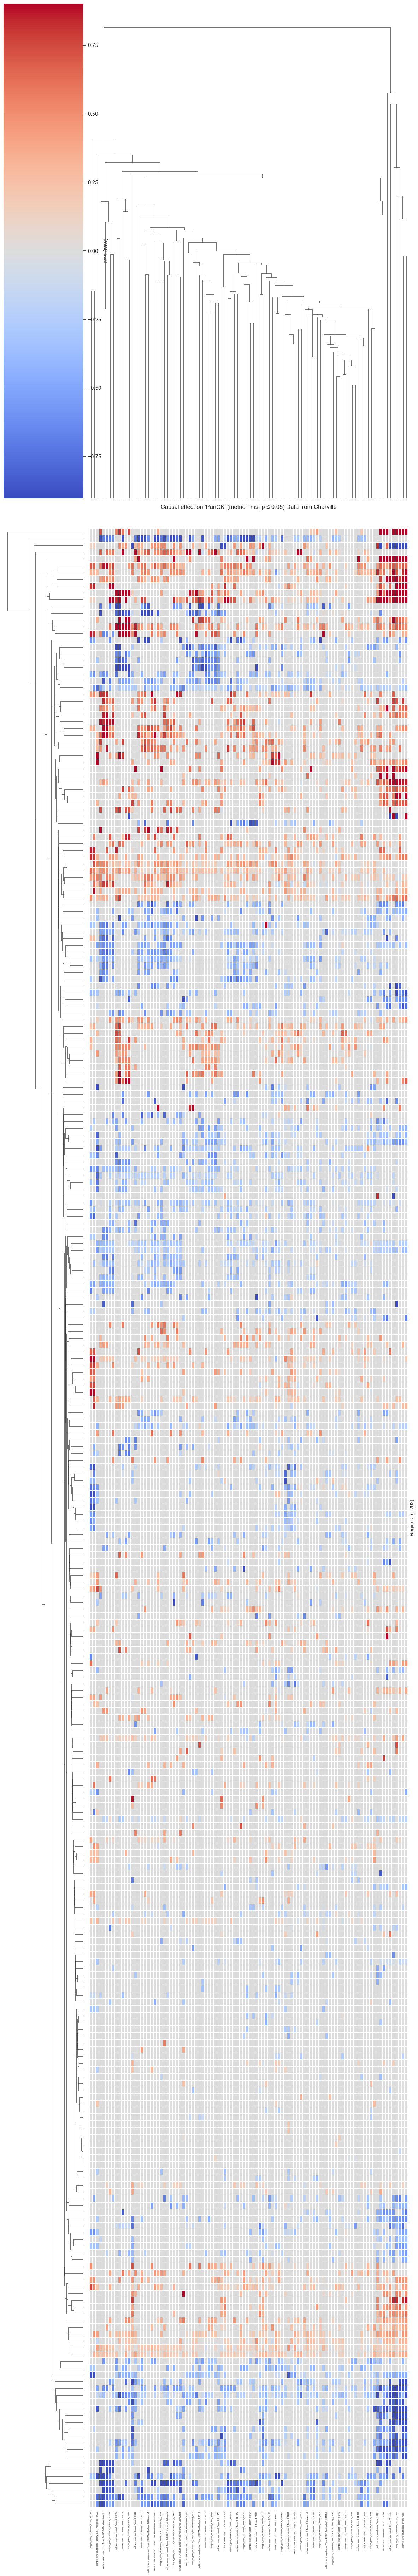

In [6]:
# >>> Example (after analysis is done)
plot_cross_region_causal_heatmap(
    out_dir=os.path.expanduser("~")+'/Expriments/Codex/charville',
    region_ids=charville_regions,
    y_var='PanCK',
    expected_sign='negative',   # PanCK expected to decrease along EMT
    top_n=100,
    top_strategy='median',
    metric='rms',
    log2_transform=False,
    row_cluster=True,
    col_cluster=True,
    title="Causal effect on 'PanCK' (metric: rms, p ≤ 0.05) Data from Charville",
    # save_path=str(TEST_DIR/'PanCK_heatmap.png'),
)


In [ ]:
# >>> Example (after analysis is done)
plot_cross_region_causal_heatmap(
    out_dir=os.path.expanduser("~")+'/Expriments/Codex/dfci',
    region_ids=dfci_regions,
    y_var='PanCK',
    expected_sign='negative',   # PanCK expected to decrease along EMT
    metric='rms',
    log2_transform=False,
    title="Causal effect on 'PanCK' (metric: rms, p ≤ 0.05) Data from DFCI",
    # save_path=str(TEST_DIR/'PanCK_heatmap.png'),
)


In [ ]:
# >>> Example (after analysis is done)
plot_cross_region_causal_heatmap(
    out_dir=os.path.expanduser("~")+'/Expriments/Codex/upmc',
    region_ids=upmc_regions,
    y_var='PanCK',
    expected_sign='negative',   # PanCK expected to decrease along EMT
    metric='rms',
    log2_transform=False,
    title="Causal effect on 'PanCK' (metric: rms, p ≤ 0.05) Data from UPMC",
    # save_path=str(TEST_DIR/'PanCK_heatmap.png'),
)
